#**Importing Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('loan_approval_dataset.csv')

#**Data Cleaning**

In [3]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [5]:
df.shape

(4269, 13)

In [6]:
df['loan_id'].duplicated().sum()

np.int64(0)

# Loan_ID is a unique identifier assigned to each loan application.

*It does not contain any meaningful information related to loan approval prediction. Since every value is unique, it does not help the model learn any useful pattern.

*Therefore, the Loan_ID column is dropped.

In [7]:
df.drop('loan_id', axis=1, inplace=True)

In [8]:
df.columns

Index([' no_of_dependents', ' education', ' self_employed', ' income_annum',
       ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [9]:
df.columns = df.columns.str.strip()

In [10]:
df['loan_status'].value_counts()

,count
loan_status,
Approved,2656
Rejected,1613


The target variable is slightly imbalanced.

Approved loans account for approximately 62% of the dataset, while rejected loans account for around 38%.

The imbalance is not severe, so the dataset can be used directly for model training.

In [11]:
df.nunique()

,0
no_of_dependents,6
education,2
self_employed,2
income_annum,98
loan_amount,378
loan_term,10
cibil_score,601
residential_assets_value,278
commercial_assets_value,188
luxury_assets_value,379


#**EDA(Exploratory Data Analysis)**

In [12]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


# Numerical Feature

In [13]:
def check_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    print(f"Column: {column}")
    print(f"Lower Bound : {lower_bound:.2f}")
    print(f"Upper Bound : {upper_bound:.2f}")
    print(f"Total Outliers : {len(outliers)}")
    print(f"Outlier Percentage : {(len(outliers)/len(df))*100:.2f}%")

    return outliers

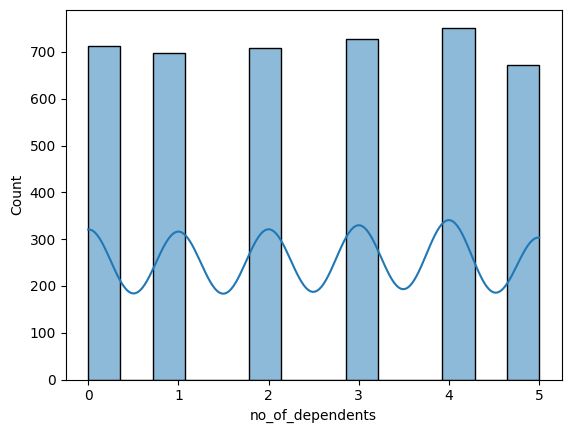

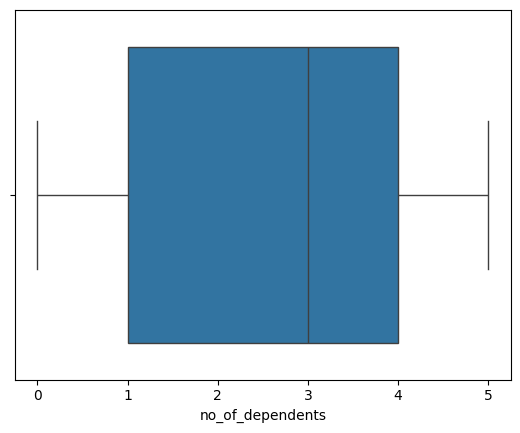

Column: no_of_dependents
Lower Bound : -3.50
Upper Bound : 8.50
Total Outliers : 0
Outlier Percentage : 0.00%


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status


In [14]:
sns.histplot(df, x='no_of_dependents', kde=True)
plt.show()
sns.boxplot(df, x='no_of_dependents')
plt.show()
check_outliers(df, 'no_of_dependents')

In [15]:
df['no_of_dependents'].describe()

,no_of_dependents
count,4269.000000
mean,2.498712
std,1.695910
min,0.000000
25%,1.000000
50%,3.000000
75%,4.000000
max,5.000000


In [16]:
df['no_of_dependents'].skew()

np.float64(-0.01797054296784964)

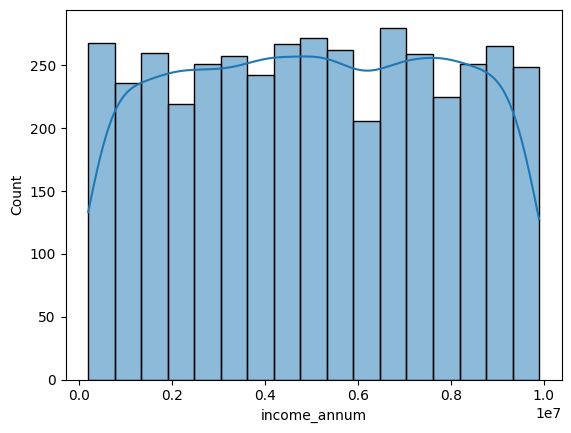

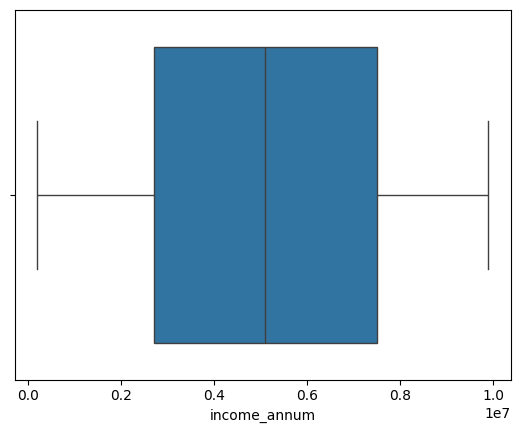

In [17]:
sns.histplot(df, x = 'income_annum' , kde = True)
plt.show()

sns.boxplot(df, x = 'income_annum')
plt.show()

In [18]:
df['income_annum'].describe()

,income_annum
count,4.269000e+03
mean,5.059124e+06
std,2.806840e+06
min,2.000000e+05
25%,2.700000e+06
50%,5.100000e+06
75%,7.500000e+06
max,9.900000e+06


In [19]:
df['income_annum'].skew()

np.float64(-0.012814425096650109)

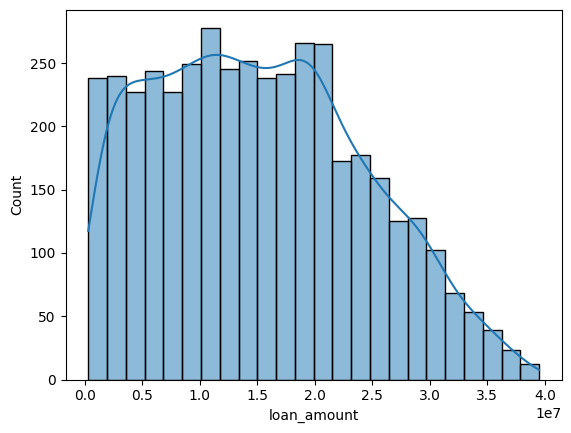

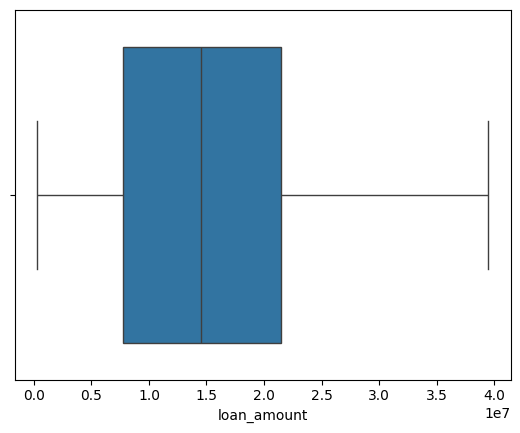

In [20]:
sns.histplot(df, x = 'loan_amount', kde = True)
plt.show()

sns.boxplot(df, x = 'loan_amount')
plt.show()

In [21]:
df['loan_amount'].describe()

,loan_amount
count,4.269000e+03
mean,1.513345e+07
std,9.043363e+06
min,3.000000e+05
25%,7.700000e+06
50%,1.450000e+07
75%,2.150000e+07
max,3.950000e+07


In [22]:
df['loan_amount'].skew()

np.float64(0.30872388482299223)

LOAN_TERM


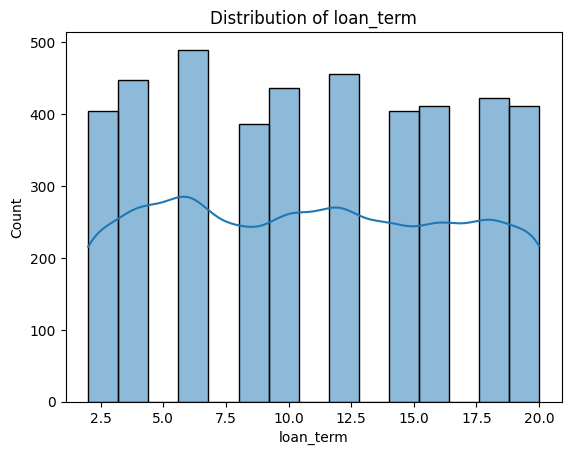

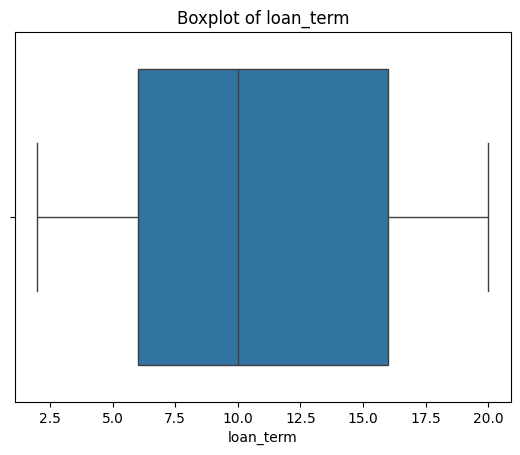

count    4269.000000
mean       10.900445
std         5.709187
min         2.000000
25%         6.000000
50%        10.000000
75%        16.000000
max        20.000000
Name: loan_term, dtype: float64

Skewness : 0.04

Column: loan_term
Lower Bound : -9.00
Upper Bound : 31.00
Total Outliers : 0
Outlier Percentage : 0.00%
CIBIL_SCORE


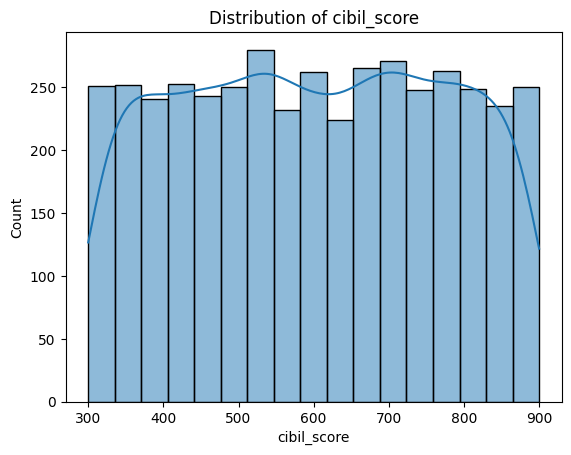

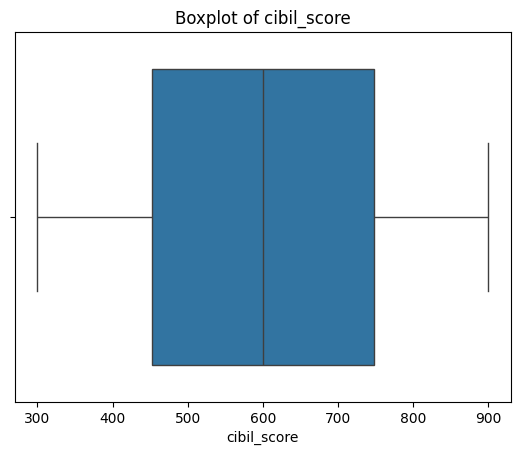

count    4269.000000
mean      599.936051
std       172.430401
min       300.000000
25%       453.000000
50%       600.000000
75%       748.000000
max       900.000000
Name: cibil_score, dtype: float64

Skewness : -0.01

Column: cibil_score
Lower Bound : 10.50
Upper Bound : 1190.50
Total Outliers : 0
Outlier Percentage : 0.00%
RESIDENTIAL_ASSETS_VALUE


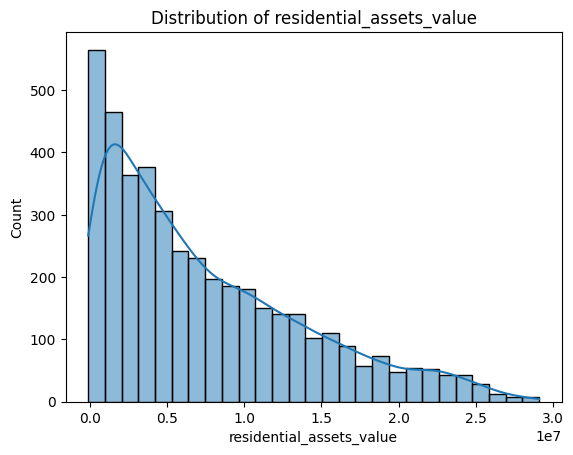

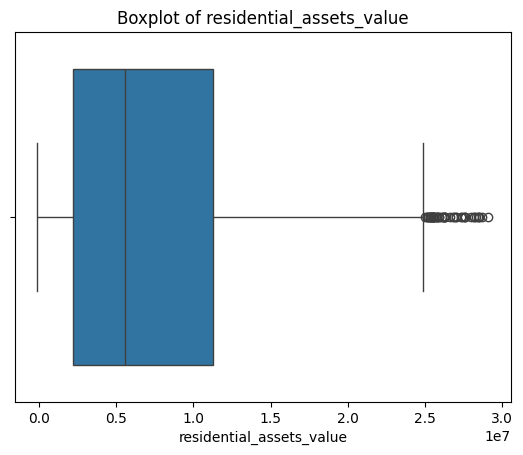

count    4.269000e+03
mean     7.472617e+06
std      6.503637e+06
min     -1.000000e+05
25%      2.200000e+06
50%      5.600000e+06
75%      1.130000e+07
max      2.910000e+07
Name: residential_assets_value, dtype: float64

Skewness : 0.98

Column: residential_assets_value
Lower Bound : -11450000.00
Upper Bound : 24950000.00
Total Outliers : 52
Outlier Percentage : 1.22%
COMMERCIAL_ASSETS_VALUE


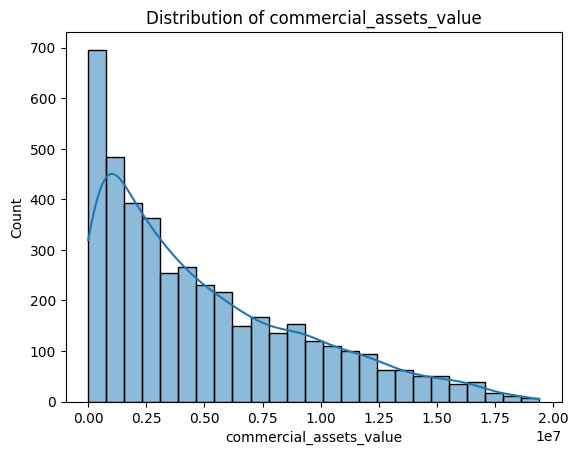

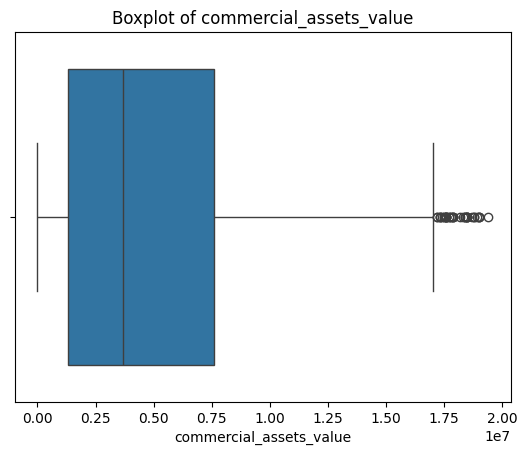

count    4.269000e+03
mean     4.973155e+06
std      4.388966e+06
min      0.000000e+00
25%      1.300000e+06
50%      3.700000e+06
75%      7.600000e+06
max      1.940000e+07
Name: commercial_assets_value, dtype: float64

Skewness : 0.96

Column: commercial_assets_value
Lower Bound : -8150000.00
Upper Bound : 17050000.00
Total Outliers : 37
Outlier Percentage : 0.87%
LUXURY_ASSETS_VALUE


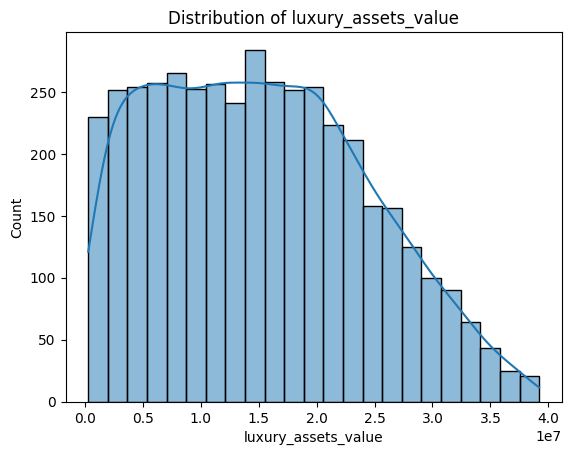

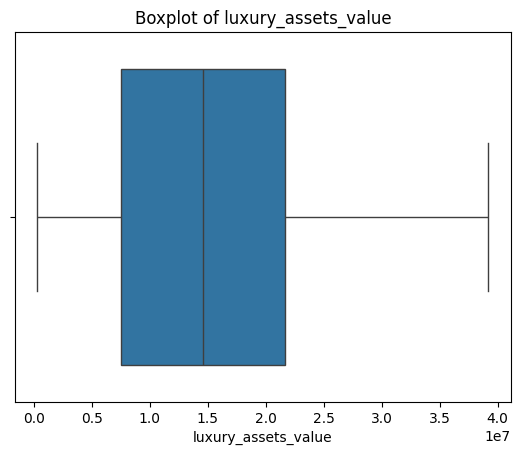

count    4.269000e+03
mean     1.512631e+07
std      9.103754e+06
min      3.000000e+05
25%      7.500000e+06
50%      1.460000e+07
75%      2.170000e+07
max      3.920000e+07
Name: luxury_assets_value, dtype: float64

Skewness : 0.32

Column: luxury_assets_value
Lower Bound : -13800000.00
Upper Bound : 43000000.00
Total Outliers : 0
Outlier Percentage : 0.00%
BANK_ASSET_VALUE


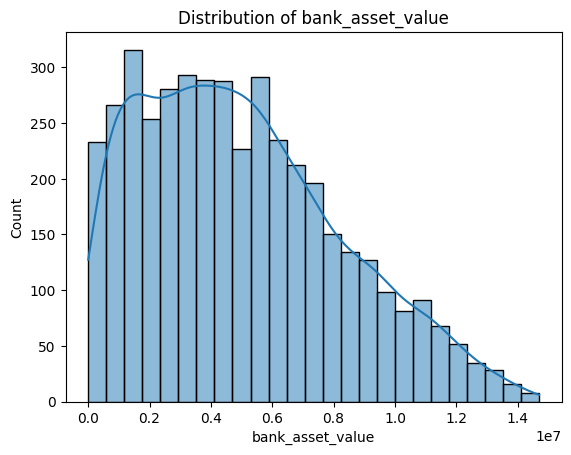

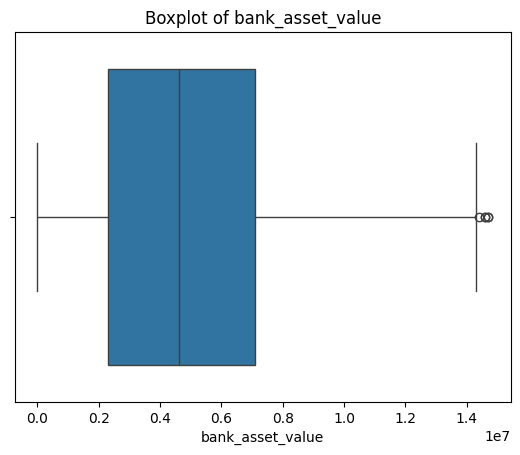

count    4.269000e+03
mean     4.976692e+06
std      3.250185e+06
min      0.000000e+00
25%      2.300000e+06
50%      4.600000e+06
75%      7.100000e+06
max      1.470000e+07
Name: bank_asset_value, dtype: float64

Skewness : 0.56

Column: bank_asset_value
Lower Bound : -4900000.00
Upper Bound : 14300000.00
Total Outliers : 5
Outlier Percentage : 0.12%


In [23]:
numerical_cols = [
    'loan_term',
    'cibil_score',
    'residential_assets_value',
    'commercial_assets_value',
    'luxury_assets_value',
    'bank_asset_value'
]

for col in numerical_cols:

    print("="*70)
    print(f"{col.upper()}")
    print("="*70)

    # Histogram
    sns.histplot(df, x=col, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

    # Boxplot
    sns.boxplot(df, x=col)
    plt.title(f"Boxplot of {col}")
    plt.show()

    # Summary
    print(df[col].describe())
    print(f"\nSkewness : {df[col].skew():.2f}\n")

    # Outliers
    check_outliers(df, col)

# No_of_Dependents Feature Analysis

* The distribution is nearly uniform with multiple peaks of similar height.
* No outliers are present, and all values fall within the expected range.
* Mean and median are very close, indicating a nearly symmetric distribution.
* The feature is almost perfectly symmetric (Skewness ≈ -0.01).
* If missing values were present, mean imputation would be appropriate because the distribution is symmetric and free from outliers.


# Income_Annum Feature Analysis

* Income_Annum is approximately uniformly distributed.
* The observations are spread across the entire range with no dominant peak.
* No outliers are present.
* Mean and median are very close, indicating an approximately symmetric distribution.
* If missing values were present, mean imputation would be appropriate because the distribution is symmetric and contains no outliers.


# Loan_Amount Feature Analysis

* Loan_Amount is approximately symmetric with a slight right skew.
* Very few customers have higher loan amounts than the majority.
* No outliers are detected.
* Mean and median are very close.
* If missing values were present, mean imputation would be appropriate because the distribution is nearly symmetric and free from outliers.


# Loan_Term Feature Analysis

* Similar observations as No_of_Dependents.
* The distribution is nearly uniform.
* No outliers are present.
* Mean and median are almost identical.
* Mean imputation would be appropriate if missing values were present.


# CIBIL_Score Feature Analysis

* Similar observations as Income_Annum.
* The values are approximately uniformly distributed.
* No outliers are detected.
* Mean and median are very close.
* Mean imputation would be appropriate if missing values were present.


# Residential_Assets_Value Feature Analysis

* The distribution is moderately right-skewed.
* Very few outliers (≈1.22%) are present.
* Mean and median are reasonably close, but the distribution is influenced by a few higher values.
* If missing values were present, median imputation would be preferred because it is more robust to skewness and outliers.


# Commercial_Assets_Value Feature Analysis

* The distribution is moderately right-skewed.
* Very few outliers are present.
* Mean is slightly higher than the median due to a few large values.
* If missing values were present, median imputation would be preferred because of the skewed distribution.


# Luxury_Assets_Value Feature Analysis

* Similar observations as Loan_Amount.
* The distribution is approximately symmetric with a slight right skew.
* No significant outliers are detected.
* Mean and median are close to each other.
* Mean imputation would be appropriate if missing values were present.


# Bank_Asset_Value Feature Analysis

* Similar observations as Loan_Amount.
* The distribution is approximately symmetric with a slight right skew.
* Very few outliers are present, but their percentage is negligible.
* Mean and median are close to each other.
* If missing values were present, mean imputation would be appropriate because the effect of the few outliers is minimal.

#**Categorical Feature**

#Univariate

education
education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64


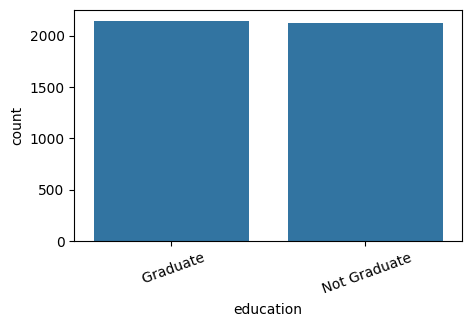

self_employed
self_employed
Yes    2150
No     2119
Name: count, dtype: int64


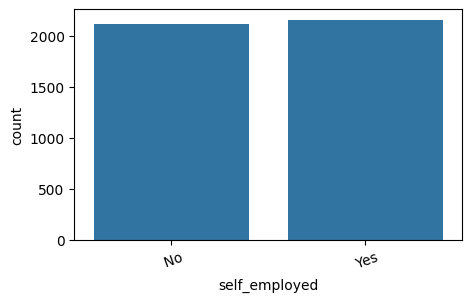

loan_status
loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64


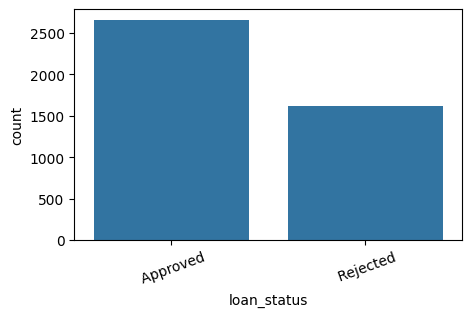

In [24]:
categorical_cols = [
    'education',
    'self_employed',
    'loan_status'
]

for col in categorical_cols:
    print("="*50)
    print(col)

    print(df[col].value_counts())

    plt.figure(figsize=(5,3))
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=20)
    plt.show()

# Education
* Most applicants are graduates.
* Non-graduate applicants are comparatively fewer.

# Self_Employed
* Most applicants are not self-employed.
* Self-employed applicants represent a smaller portion of the dataset.

# Loan_Status (Target)
* Approved loans are more than rejected loans.
* The target variable is slightly imbalanced.

#Bivariate

education vs Loan Status
loan_status    Approved   Rejected
education                         
Graduate      62.453358  37.546642
Not Graduate  61.976471  38.023529


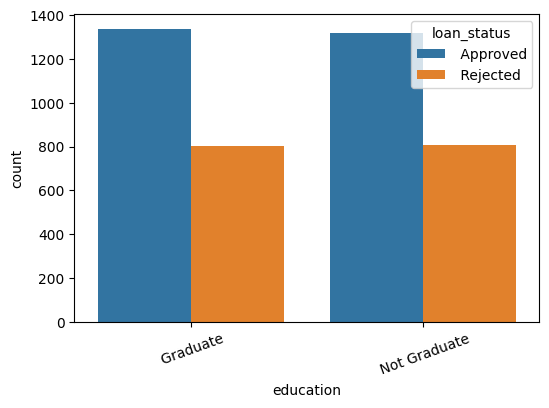

self_employed vs Loan Status
loan_status     Approved   Rejected
self_employed                      
No             62.199151  37.800849
Yes            62.232558  37.767442


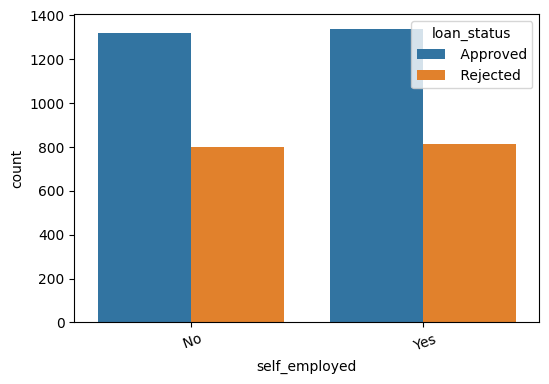

In [25]:
categorical_cols = [
    'education',
    'self_employed'
]

for col in categorical_cols:

    print("="*60)
    print(f"{col} vs Loan Status")

    print(pd.crosstab(df[col], df['loan_status'], normalize='index')*100)

    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, hue='loan_status')
    plt.xticks(rotation=20)
    plt.show()

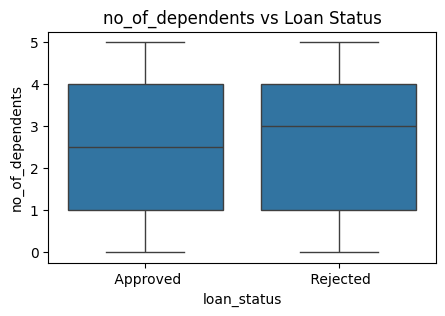

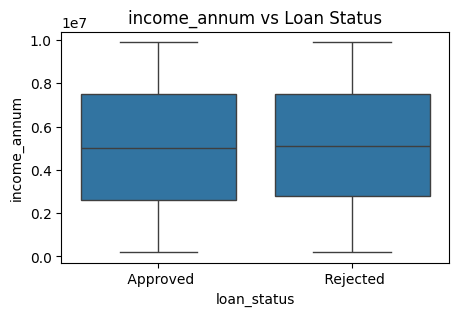

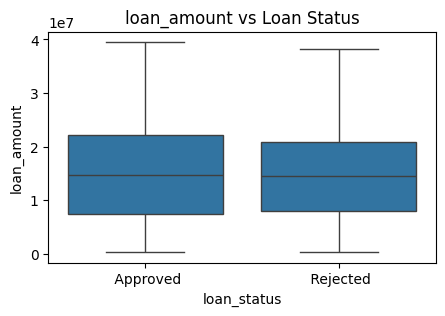

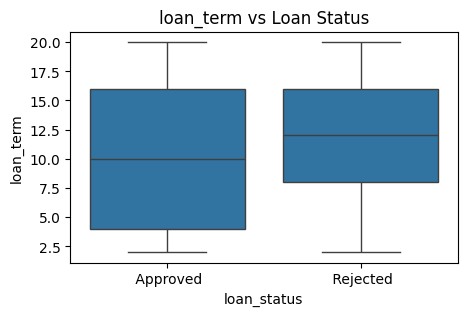

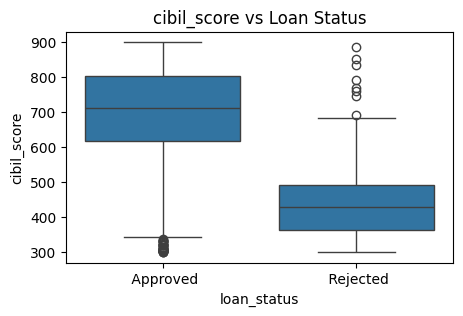

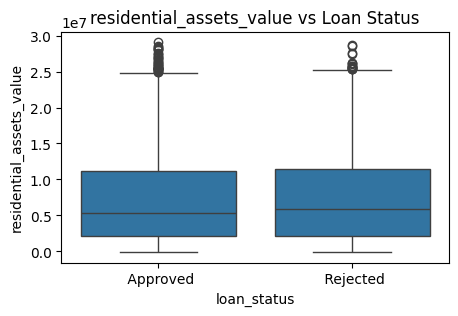

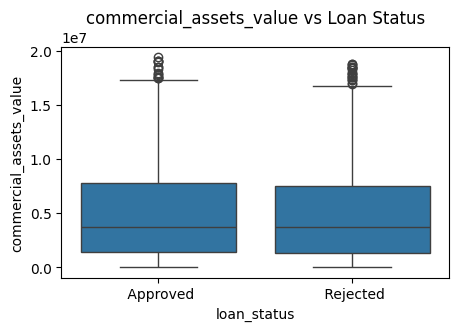

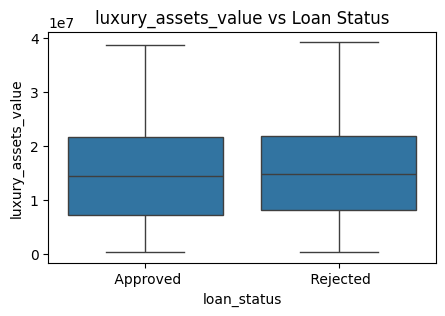

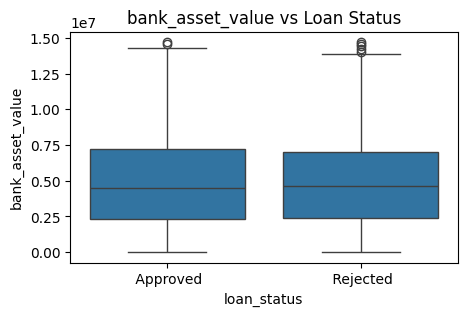

In [26]:
numerical_cols = [
    'no_of_dependents',
    'income_annum',
    'loan_amount',
    'loan_term',
    'cibil_score',
    'residential_assets_value',
    'commercial_assets_value',
    'luxury_assets_value',
    'bank_asset_value'
]

for col in numerical_cols:

    plt.figure(figsize=(5,3))
    sns.boxplot(data=df, x='loan_status', y=col)
    plt.title(f"{col} vs Loan Status")
    plt.show()

# Numerical Features vs Loan Status

### No_of_Dependents vs Loan Status
* Approved and Rejected applicants have a very similar distribution.
* The median values are close, indicating a weak relationship with loan approval.
* This feature may have limited predictive power but will be retained.

### Income_Annum vs Loan Status
* Approved applicants generally have slightly higher annual incomes than rejected applicants.
* The distributions overlap, but there is a noticeable difference in the median.
* Income may contribute to loan approval prediction.

### Loan_Amount vs Loan Status
* Approved and Rejected applicants have a very similar loan amount distribution.
* The median values are close and the distributions largely overlap.
* Loan Amount alone does not appear to strongly influence loan approval.

### Loan_Term vs Loan Status
* Loan Term shows a very similar distribution for both approved and rejected applicants.
* The median values are close, indicating a weak relationship with the target.

### CIBIL_Score vs Loan Status
* Approved applicants generally have significantly higher CIBIL scores than rejected applicants.
* There is a clear separation between the two classes with very little overlap.
* A few outliers are present in both groups.
* CIBIL Score appears to be one of the strongest predictors of loan approval.

### Residential_Assets_Value vs Loan Status
* Approved applicants generally have slightly higher residential asset values.
* The distributions overlap considerably, but the median is slightly higher for approved applicants.
* This feature may provide moderate predictive information.

### Commercial_Assets_Value vs Loan Status
* Similar observations as Residential_Assets_Value.
* Approved applicants tend to have slightly higher commercial asset values.
* The distributions overlap, indicating a moderate relationship with loan approval.

### Luxury_Assets_Value vs Loan Status
* Similar observations as Residential_Assets_Value.
* Approved applicants generally possess slightly higher luxury asset values.
* The feature may provide moderate predictive information.

### Bank_Asset_Value vs Loan Status
* Similar observations as Residential_Assets_Value.
* Approved applicants tend to have slightly higher bank asset values.
* The distributions overlap, suggesting a moderate relationship with loan approval.

#**Encoding**

#Label Encoding

In [27]:
print(df['education'].unique())
print(df['self_employed'].unique())
print(df['loan_status'].unique())

[' Graduate' ' Not Graduate']
[' No' ' Yes']
[' Approved' ' Rejected']


In [28]:
df = df.apply(lambda x: x.str.strip() if x.dtype == 'object' else x)

In [29]:
# Label Encoding

df['education'] = df['education'].map({
    'Graduate': 1,
    'Not Graduate': 0
})

df['self_employed'] = df['self_employed'].map({
    'Yes': 1,
    'No': 0
})

df['loan_status'] = df['loan_status'].map({
    'Approved': 1,
    'Rejected': 0
})

#**Correlation**

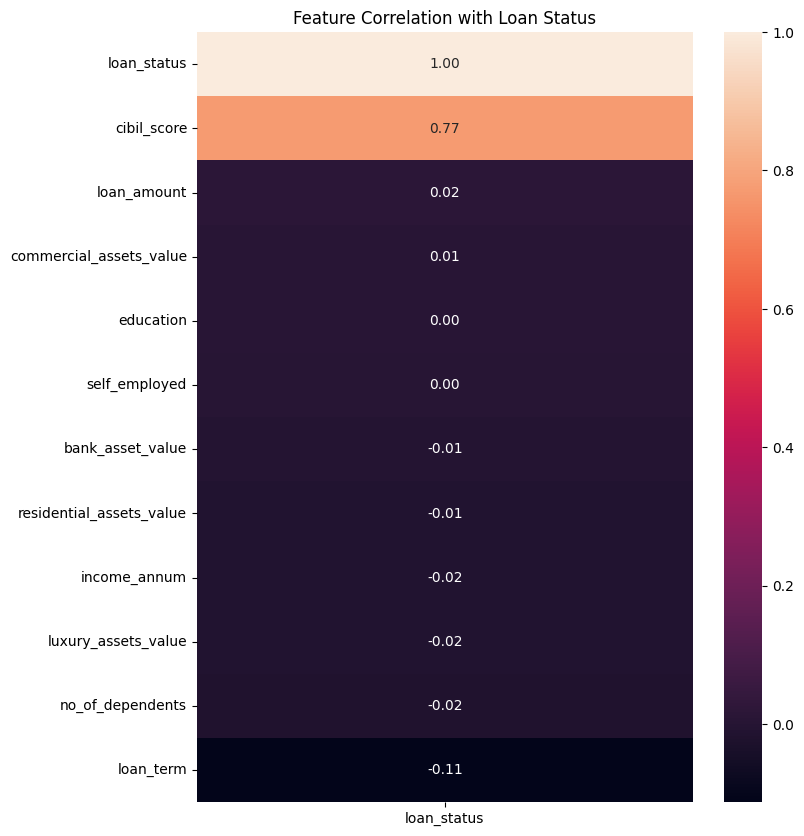

In [30]:
plt.figure(figsize=(8,10))

sns.heatmap(
    df.corr(numeric_only=True)[['loan_status']].sort_values(by='loan_status', ascending=False),
    annot=True,
    fmt='.2f'
)

plt.title("Feature Correlation with Loan Status")
plt.show()

CIBIL Score
→ Very Strong Positive Correlation (0.77)
→ Most Important Feature

Loan Term
→ Weak Negative Correlation (-0.11)

Remaining Features
→ Very Weak Linear Correlation

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   no_of_dependents          4269 non-null   int64
 1   education                 4269 non-null   int64
 2   self_employed             4269 non-null   int64
 3   income_annum              4269 non-null   int64
 4   loan_amount               4269 non-null   int64
 5   loan_term                 4269 non-null   int64
 6   cibil_score               4269 non-null   int64
 7   residential_assets_value  4269 non-null   int64
 8   commercial_assets_value   4269 non-null   int64
 9   luxury_assets_value       4269 non-null   int64
 10  bank_asset_value          4269 non-null   int64
 11  loan_status               4269 non-null   int64
dtypes: int64(12)
memory usage: 400.3 KB


#**Train-Test-Split**

In [32]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

In [33]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#**Feature Scaling**

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#**Logistic Regression**

In [36]:
from sklearn.linear_model import LogisticRegression
model_LR = LogisticRegression()
model_LR.fit(X_train_scaled, y_train)

LogisticRegression()

In [37]:
y_prediction_LR = model_LR.predict(X_test_scaled)

In [38]:
accuracy_LR = accuracy_score(y_test, y_prediction_LR)
print("Accuracy:", accuracy_LR)

Accuracy: 0.905152224824356


#**KNN (K-Nearest Neighbour)**

In [39]:
from sklearn.neighbors import KNeighborsClassifier
model_KNN = KNeighborsClassifier()
model_KNN.fit(X_train_scaled, y_train)
y_prediction_KNN = model_KNN.predict(X_test_scaled)
accuracy_KNN = accuracy_score(y_test, y_prediction_KNN)
print("Accuracy:", accuracy_KNN)

Accuracy: 0.892271662763466


#**SVM (Support Vector Machine)**

In [40]:
from sklearn.svm import SVC
model_SVM = SVC()
model_SVM.fit(X_train_scaled, y_train)
y_prediction_SVM = model_SVM.predict(X_test_scaled)
accuracy_SVM = accuracy_score(y_test, y_prediction_SVM)
print("Accuracy:", accuracy_SVM)

Accuracy: 0.9238875878220141


#**Naive Bayes**

In [41]:
from sklearn.naive_bayes import GaussianNB
model_NB = GaussianNB()
model_NB.fit(X_train_scaled, y_train)
y_prediction_NB = model_NB.predict(X_test_scaled)
accuracy_NB = accuracy_score(y_test, y_prediction_NB)
print("Accuracy:", accuracy_NB)

Accuracy: 0.936768149882904


#**Decision Tree**

In [42]:
from sklearn.tree import DecisionTreeClassifier
model_DT = DecisionTreeClassifier(random_state=42)
model_DT.fit(X_train, y_train)
y_prediction_DT = model_DT.predict(X_test)
accuracy_DT = accuracy_score(y_test, y_prediction_DT)
print("Accuracy:", accuracy_DT)

Accuracy: 0.977751756440281


#**Random Forest**

In [43]:
from sklearn.ensemble import RandomForestClassifier
model_RF = RandomForestClassifier(random_state=42)
model_RF.fit(X_train, y_train)
y_prediction_RF = model_RF.predict(X_test)
accuracy_RF = accuracy_score(y_test, y_prediction_RF)
print("Accuracy:", accuracy_RF)

Accuracy: 0.9800936768149883


# Model Performance Comparison

* Six Machine Learning algorithms were trained and evaluated for Loan Approval Prediction.

| Model | Accuracy |
|--------|---------:|
| Random Forest | **98.01%** |
| Decision Tree | **97.78%** |
| Gaussian Naive Bayes | **93.68%** |
| Support Vector Machine | **92.39%** |
| Logistic Regression | **90.52%** |
| K-Nearest Neighbors | **89.23%** |

## Conclusion

* Random Forest achieved the highest accuracy (98.01%), making it the best-performing model.
* Decision Tree also performed exceptionally well with an accuracy of 97.78%.
* Gaussian Naive Bayes and SVM achieved strong performance above 92%.
* Logistic Regression and KNN also produced good results with accuracies above 89%.
* Overall, the dataset is highly predictable, with **CIBIL Score** being the most influential feature.
* Based on the evaluation, **Random Forest** was selected as the final model for Loan Approval Prediction.